Understand where the model fails

Detect systematic bias

Decide what to fix (if anything)

In [12]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

MODEL_PATH = r"../data/interim/models/hgb_y_Assets_it900_lr0.03_d8.joblib"

model = joblib.load(MODEL_PATH)
print("Model loaded:", type(model))


Model loaded: <class 'dict'> <class 'dict'>


In [ ]:
import os
from pathlib import Path
import pandas as pd
from zenml.client import Client

client = Client()
latest_run = client.get_pipeline("training").last_run
# Paths coming from ZenML feature_engineering_step
val_fe_path  = latest_run.steps["feature_engineering_step"].outputs["output_1"][0].load()
test_fe_path = latest_run.steps["feature_engineering_step"].outputs["output_2"][0].load()

print("Raw val_fe_path:", val_fe_path)
print("Raw test_fe_path:", test_fe_path)
print("CWD:", os.getcwd())

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [
        Path(p),
        Path("..") / p,
        Path("..") / ".." / p,
        Path("..") / ".." / ".." / p,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p} (tried {len(candidates)} candidates)")

val_fe_path_resolved = resolve_existing(val_fe_path)
test_fe_path_resolved = resolve_existing(test_fe_path)

print("Resolved val_fe_path:", val_fe_path_resolved)
print("Resolved test_fe_path:", test_fe_path_resolved)
df_eval = pd.read_parquet(val_fe_path_resolved).copy()
df_eval["end"] = pd.to_datetime(
    ["end"], errors="coerce")

print("df_eval shape:", df_eval.shape)
display(df_eval.head(3))


Raw val_fe_path: ./data/interim/val_fe.parquet ./data/interim/val_fe.parquet
Raw test_fe_path: ./data/interim/test_fe.parquet ./data/interim/test_fe.parquet
CWD: d:\balance-sheet-ml\notebooks d:\balance-sheet-ml\notebooks
Resolved val_fe_path: ..\data\interim\val_fe.parquet ..\data\interim\val_fe.parquet
Resolved test_fe_path: ..\data\interim\test_fe.parquet ..\data\interim\test_fe.parquet
df_eval shape: (9337, 157) (9337, 157)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity,cash_to_assets_delta1,cash_to_assets_pct1,cash_to_assets_rollmean4,cash_to_assets_rollstd4,current_assets_to_assets_delta1,current_assets_to_assets_pct1,current_assets_to_assets_rollmean4,current_assets_to_assets_rollstd4,liab_to_assets_delta1,liab_to_assets_pct1,liab_to_assets_rollmean4,liab_to_assets_rollstd4,equity_to_assets_delta1,equity_to_assets_pct1,equity_to_assets_rollmean4,equity_to_assets_rollstd4,current_liab_to_liab_delta1,current_liab_to_liab_pct1,current_liab_to_liab_rollmean4,current_liab_to_liab_rollstd4,ppe_to_assets_delta1,ppe_to_assets_pct1,ppe_to_assets_rollmean4,ppe_to_assets_rollstd4,goodwill_to_assets_delta1,goodwill_to_assets_pct1,goodwill_to_assets_rollmean4,goodwill_to_assets_rollstd4,intangibles_to_assets_delta1,intangibles_to_assets_pct1,intangibles_to_assets_rollmean4,intangibles_to_assets_rollstd4,wc_to_assets_delta1,wc_to_assets_pct1,wc_to_assets_rollmean4,wc_to_assets_rollstd4,debt_to_assets_delta1,debt_to_assets_pct1,debt_to_assets_rollmean4,debt_to_as

In [21]:
from zenml.client import Client

client = Client()
pipe = client.get_pipeline("training")

for i, run in enumerate(pipe.runs[:5]):
    print(i, run.name)


0 training_pipeline-2026_01_03-01_08_02_556793 training_pipeline-2026_01_03-01_08_02_556793
1 training_pipeline-2026_01_03-01_07_19_774899 training_pipeline-2026_01_03-01_07_19_774899
2 training_pipeline-2026_01_02-23_34_29_702572 training_pipeline-2026_01_02-23_34_29_702572
3 training_pipeline-2026_01_02-23_31_28_771994 training_pipeline-2026_01_02-23_31_28_771994
4 training_pipeline-2026_01_02-23_27_44_850697 training_pipeline-2026_01_02-23_27_44_850697


In [ ]:
run = pipe.last_run

model_path = (
    run.steps["train_tree_step"]
    .outputs["output_0"][0]
    .load()
)

print("ZenML model path:", model_path)


ZenML model path: data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib


In [24]:
import joblib
from pathlib import Path

# model_path from ZenML run
model_path = latest_run.steps["train_tree_step"].outputs["output_0"][0].load()
print("ZenML model path:", model_path)

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [
        Path(p),
        Path("..") / p,
        Path("..") / ".." / p,
        Path("..") / ".." / ".." / p,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p}")

model_path_resolved = resolve_existing(model_path)
print("Resolved model path:", model_path_resolved)

bundle = joblib.load(model_path_resolved)
model = bundle["model"]
FEATURES = bundle["features"]
TARGET = bundle["target"]


ZenML model path: data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib
Resolved model path: ..\data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib ..\data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib


In [25]:
import joblib

MODEL_PATH = r"../data/interim/models/hgb_y_Assets_it900_lr0.03_d8.joblib"
bundle = joblib.load(MODEL_PATH)

print("Loaded object type:", type(bundle))

# If it's a bundle dict, extract model + feature list if present
if isinstance(bundle, dict):
    print("Bundle keys:", list(bundle.keys()))
    
    # common keys
    model = bundle.get("model") or bundle.get("estimator") or bundle.get("regressor")
    feat_list = bundle.get("features") or bundle.get("feature_names") or bundle.get("columns")
    
    print("Extracted model type:", type(model))
    print("Has feature list?", feat_list is not None, "| n_features_in_bundle:", None if feat_list is None else len(feat_list))
else:
    model = bundle
    feat_list = None
    print("Model type:", type(model))


Loaded object type: <class 'dict'> <class 'dict'>
Bundle keys: ['model', 'features', 'target'] ['model', 'features', 'target']
Extracted model type: <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.pipeline.Pipeline'>
Has feature list? True | n_features_in_bundle: 81 True | n_features_in_bundle: 81


In [26]:
# pull engineered artifacts from the feature_engineering_step
fe_out0 = latest_run.steps["feature_engineering_step"].outputs["output_0"][0].load()
fe_out1 = latest_run.steps["feature_engineering_step"].outputs["output_1"][0].load()
fe_out2 = latest_run.steps["feature_engineering_step"].outputs["output_2"][0].load()

print("feature_engineering outputs:")
print("out0 type:", type(fe_out0), "| value preview:", str(fe_out0)[:200])
print("out1 type:", type(fe_out1), "| value preview:", str(fe_out1)[:200])
print("out2 type:", type(fe_out2), "| value preview:", str(fe_out2)[:200])


feature_engineering outputs:
out0 type: <class 'str'> | value preview: ./data/interim/train_fe.parquet <class 'str'> | value preview: ./data/interim/train_fe.parquet
out1 type: <class 'str'> | value preview: ./data/interim/val_fe.parquet <class 'str'> | value preview: ./data/interim/val_fe.parquet
out2 type: <class 'str'> | value preview: ./data/interim/test_fe.parquet <class 'str'> | value preview: ./data/interim/test_fe.parquet


In [27]:
import pandas as pd
from pathlib import Path

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [Path(p), Path("..")/p, Path("..")/".."/p, Path("..")/".."/".."/p]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p}")

val_fe_path = latest_run.steps["feature_engineering_step"].outputs["output_1"][0].load()
val_fe_path = resolve_existing(val_fe_path)

print("Resolved val_fe_path:", val_fe_path)

df_eval = pd.read_parquet(val_fe_path).copy()
df_eval["end"] = pd.to_datetime(df_eval["end"], errors="coerce")
print("df_eval (val_fe) shape:", df_eval.shape)

# quick sanity: missing features vs bundle
FEATURES = bundle["features"]
missing = [c for c in FEATURES if c not in df_eval.columns]
print("Missing features in val_fe:", len(missing))
if len(missing):
    print("Example missing:", missing[:10])

display(df_eval.head(3))


Resolved val_fe_path: ..\data\interim\val_fe.parquet ..\data\interim\val_fe.parquet
df_eval (val_fe) shape: (9337, 157) (9337, 157)
Missing features in val_fe: 0 0


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity,cash_to_assets_delta1,cash_to_assets_pct1,cash_to_assets_rollmean4,cash_to_assets_rollstd4,current_assets_to_assets_delta1,current_assets_to_assets_pct1,current_assets_to_assets_rollmean4,current_assets_to_assets_rollstd4,liab_to_assets_delta1,liab_to_assets_pct1,liab_to_assets_rollmean4,liab_to_assets_rollstd4,equity_to_assets_delta1,equity_to_assets_pct1,equity_to_assets_rollmean4,equity_to_assets_rollstd4,current_liab_to_liab_delta1,current_liab_to_liab_pct1,current_liab_to_liab_rollmean4,current_liab_to_liab_rollstd4,ppe_to_assets_delta1,ppe_to_assets_pct1,ppe_to_assets_rollmean4,ppe_to_assets_rollstd4,goodwill_to_assets_delta1,goodwill_to_assets_pct1,goodwill_to_assets_rollmean4,goodwill_to_assets_rollstd4,intangibles_to_assets_delta1,intangibles_to_assets_pct1,intangibles_to_assets_rollmean4,intangibles_to_assets_rollstd4,wc_to_assets_delta1,wc_to_assets_pct1,wc_to_assets_rollmean4,wc_to_assets_rollstd4,debt_to_assets_delta1,debt_to_assets_pct1,debt_to_assets_rollmean4,debt_to_as

In [28]:
TARGET = bundle["target"]
model = bundle["model"]
FEATURES = bundle["features"]

X = df_eval[FEATURES]
y_true = df_eval[TARGET]

y_pred = model.predict(X)

df_eval = df_eval.copy()
df_eval["y_pred"] = y_pred
df_eval["residual"] = y_true - y_pred
df_eval["abs_error"] = df_eval["residual"].abs()

display(df_eval[["cik", "end", TARGET, "y_pred", "residual", "abs_error"]].head(10))
print("Rows scored:", len(df_eval))


,cik,end,y_Assets,y_pred,residual,abs_error
0,0000001750,2025-02-28,0.003434,0.105835,-0.102402,0.102402
1,0000001800,2025-03-31,0.000418,-0.012786,0.013203,0.013203
2,0000001961,2023-12-31,1.708563,0.546124,1.162439,1.162439
3,0000002034,2018-06-30,0.007634,0.021152,-0.013518,0.013518
4,0000002488,2025-03-29,0.033020,0.000602,0.032418,0.032418
5,0000002491,2014-03-31,-0.013464,0.120767,-0.134231,0.134231
6,0000002969,2025-03-31,-0.029012,0.067971,-0.096983,0.096983
7,0000003116,2019-09-30,-0.345943,0.055539,-0.401482,0.401482
8,0000003197,2025-03-31,0.230980,0.096385,0.134595,0.134595
9,0000003453,2014-09-30,-0.002789,0.042001,-0.044790,0.044790


Rows scored: 9337 9337


In [29]:
import numpy as np

print("Rows:", len(df_eval))
print("Residual mean:", df_eval["residual"].mean())
print("Residual std:", df_eval["residual"].std())
print("MAE:", df_eval["abs_error"].mean())
print("Median AE:", df_eval["abs_error"].median())

display(
    df_eval.sort_values("abs_error", ascending=False)[
        ["cik","end", TARGET, "y_pred", "residual", "abs_error"]
    ].head(20)
)


Rows: 9337 9337
Residual mean: -0.01771257600514326 -0.01771257600514326
Residual std: 0.5372112460756765 0.5372112460756765
MAE: 0.2704737342908382 0.2704737342908382
Median AE: 0.09472399356878958 0.09472399356878958


,cik,end,y_Assets,y_pred,residual,abs_error
5554,0001418115,2021-03-31,-3.000000,2.134636,-5.134636,5.134636
4966,0001373853,2013-08-31,-2.740840,1.311584,-4.052424,4.052424
7450,0001571636,2018-12-31,2.829655,-1.146457,3.976112,3.976112
4903,0001368761,2015-09-30,-2.240710,1.484452,-3.725162,3.725162
4926,0001370816,2012-10-31,-3.000000,0.586072,-3.586072,3.586072
8118,0001635748,2019-12-31,3.000000,-0.571258,3.571258,3.571258
8257,0001655971,2019-12-31,-3.000000,0.444668,-3.444668,3.444668
980,0000724742,2024-03-31,-3.000000,0.381376,-3.381376,3.381376
7599,0001582249,2023-06-30,3.000000,-0.379411,3.379411,3.379411
4222,0001290658,2024-09-30,1.991119,-1.368235,3.359354,3.359354


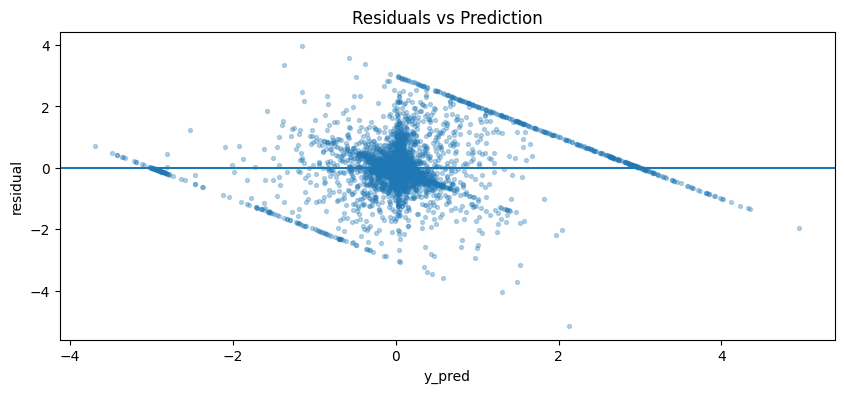

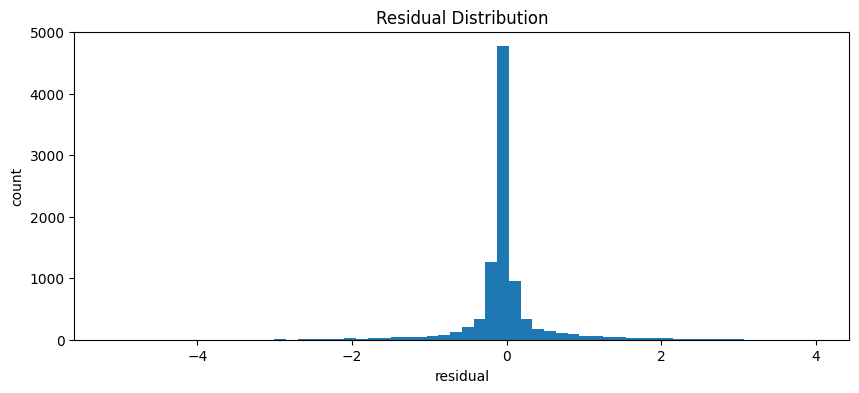

In [30]:
import matplotlib.pyplot as plt

# 1) residuals vs prediction
plt.figure(figsize=(10,4))
plt.scatter(df_eval["y_pred"], df_eval["residual"], s=8, alpha=0.3)
plt.axhline(0)
plt.title("Residuals vs Prediction")
plt.xlabel("y_pred")
plt.ylabel("residual")
plt.show()

# 2) histogram of residuals
plt.figure(figsize=(10,4))
plt.hist(df_eval["residual"].dropna(), bins=60)
plt.title("Residual Distribution")
plt.xlabel("residual")
plt.ylabel("count")
plt.show()


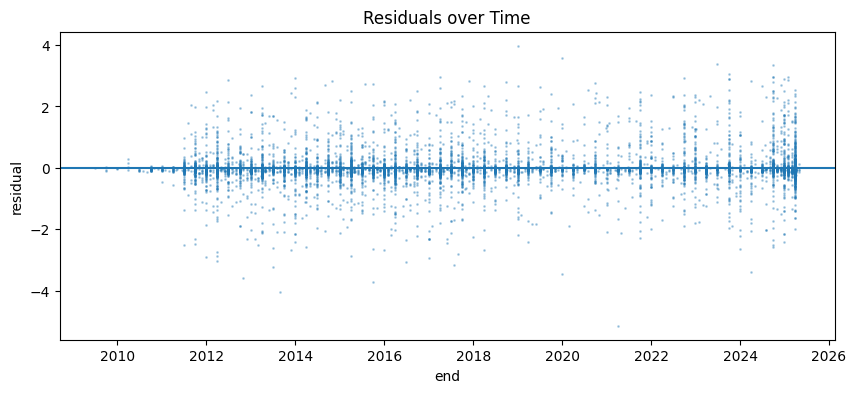

In [31]:
tmp = df_eval.dropna(subset=["end"]).sort_values("end")

plt.figure(figsize=(10,4))
plt.plot(tmp["end"], tmp["residual"], ".", markersize=2, alpha=0.3)
plt.axhline(0)
plt.title("Residuals over Time")
plt.xlabel("end")
plt.ylabel("residual")
plt.show()


MAE:  0.270474
RMSE: 0.537474
R2:   0.543360
Residual mean: -0.01771257600514326 -0.01771257600514326
Residual std:  0.5371824774331371 0.5371824774331371


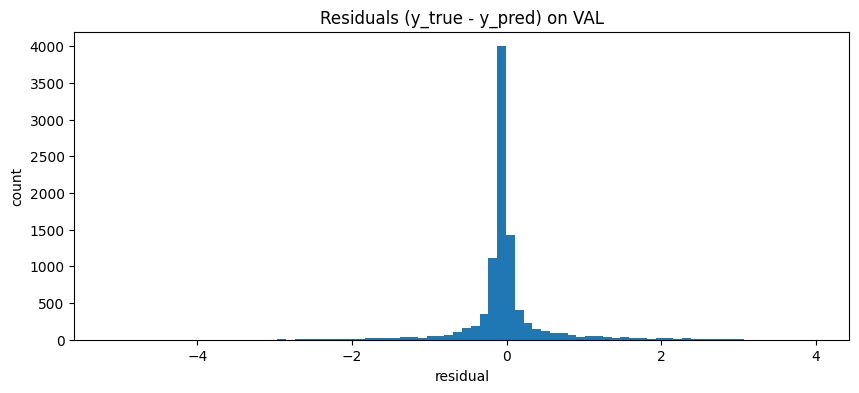

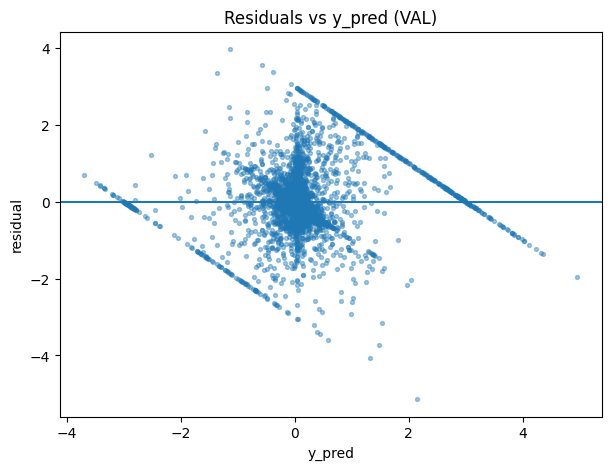

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = df_eval[TARGET].values
y_pred = df_eval["y_pred"].values
resid  = df_eval["residual"].values

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = float(np.sqrt(mse))
r2   = r2_score(y_true, y_pred)

print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2:   {r2:.6f}")
print("Residual mean:", float(np.mean(resid)))
print("Residual std: ", float(np.std(resid)))

plt.figure(figsize=(10,4))
plt.hist(resid, bins=80)
plt.title("Residuals (y_true - y_pred) on VAL")
plt.xlabel("residual")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_pred, resid, s=8, alpha=0.4)
plt.axhline(0)
plt.title("Residuals vs y_pred (VAL)")
plt.xlabel("y_pred")
plt.ylabel("residual")
plt.show()
